# Dataset Comparison Analysis

This notebook analyzes the current state of both datasets:
- Synthetic images from `/raid/mpsych/OMAMA/DATA/data/train/`
- Original converted PNGs from `/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original/`

We will identify all differences in dimensions, pixel ranges, and visual appearance.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from tqdm import tqdm
import random

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Define paths
SYNTHETIC_PATH = '/raid/mpsych/OMAMA/DATA/data/train/'
ORIGINAL_PNG_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original/'

# Verify paths exist
print(f"Synthetic path exists: {os.path.exists(SYNTHETIC_PATH)}")
print(f"Original PNG path exists: {os.path.exists(ORIGINAL_PNG_PATH)}")


Synthetic path exists: True
Original PNG path exists: True


In [3]:
# Get file lists
synthetic_files = sorted(glob.glob(os.path.join(SYNTHETIC_PATH, '*.png')))
original_files = sorted(glob.glob(os.path.join(ORIGINAL_PNG_PATH, '*.png')))

print(f"Found {len(synthetic_files)} synthetic images")
print(f"Found {len(original_files)} original images")

print(f"\nSample synthetic files:")
for f in synthetic_files[:3]:
    print(f"  {os.path.basename(f)}")

print(f"\nSample original files:")
for f in original_files[:3]:
    print(f"  {os.path.basename(f)}")


Found 99999 synthetic images
Found 163568 original images

Sample synthetic files:
  sample_0.png
  sample_1.png
  sample_10.png

Sample original files:
  100000039159562031368112550794429920461.png
  100000201190603337191863609201535272336.png
  100001062780186333300160449315992055513.png


## Step 1: Analyze Dimensions


In [4]:
# Check dimensions of 100 random samples from each dataset
print("Analyzing dimensions...\n")

# Synthetic dimensions
synthetic_sample = random.sample(synthetic_files, min(100, len(synthetic_files)))
synthetic_dims = []
for f in tqdm(synthetic_sample, desc="Checking synthetic dimensions"):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        synthetic_dims.append(img.shape)

# Original dimensions
original_sample = random.sample(original_files, min(100, len(original_files)))
original_dims = []
for f in tqdm(original_sample, desc="Checking original dimensions"):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        original_dims.append(img.shape)

print("\n" + "="*70)
print("DIMENSION ANALYSIS")
print("="*70)
print(f"\nSynthetic images:")
print(f"  Most common dimension: {max(set(synthetic_dims), key=synthetic_dims.count)}")
print(f"  Unique dimensions found: {set(synthetic_dims)}")

print(f"\nOriginal images:")
print(f"  Most common dimension: {max(set(original_dims), key=original_dims.count)}")
print(f"  Unique dimensions found: {set(original_dims)}")


Analyzing dimensions...



Checking original dimensions: 100%|████████████████████████████████████████████████| 100/100 [00:00<00:00, 335.74it/s]


DIMENSION ANALYSIS

Synthetic images:
  Most common dimension: (640, 512)
  Unique dimensions found: {(640, 512)}

Original images:
  Most common dimension: (512, 512)
  Unique dimensions found: {(512, 512)}


## Step 2: Analyze Pixel Value Ranges


In [5]:
# Analyze pixel values from 50 random samples
print("Analyzing pixel value ranges...\n")

synthetic_stats = {'min': [], 'max': [], 'mean': [], 'std': []}
original_stats = {'min': [], 'max': [], 'mean': [], 'std': []}

# Synthetic stats
syn_sample = random.sample(synthetic_files, min(50, len(synthetic_files)))
for f in tqdm(syn_sample, desc="Analyzing synthetic pixels"):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        synthetic_stats['min'].append(img.min())
        synthetic_stats['max'].append(img.max())
        synthetic_stats['mean'].append(img.mean())
        synthetic_stats['std'].append(img.std())

# Original stats
orig_sample = random.sample(original_files, min(50, len(original_files)))
for f in tqdm(orig_sample, desc="Analyzing original pixels"):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        original_stats['min'].append(img.min())
        original_stats['max'].append(img.max())
        original_stats['mean'].append(img.mean())
        original_stats['std'].append(img.std())

print("\n" + "="*70)
print("PIXEL VALUE ANALYSIS")
print("="*70)

print("\nSynthetic images:")
print(f"  Min values: {np.min(synthetic_stats['min']):.1f} - {np.max(synthetic_stats['min']):.1f}")
print(f"  Max values: {np.min(synthetic_stats['max']):.1f} - {np.max(synthetic_stats['max']):.1f}")
print(f"  Mean: {np.mean(synthetic_stats['mean']):.1f} ± {np.std(synthetic_stats['mean']):.1f}")
print(f"  Std: {np.mean(synthetic_stats['std']):.1f} ± {np.std(synthetic_stats['std']):.1f}")

print("\nOriginal images:")
print(f"  Min values: {np.min(original_stats['min']):.1f} - {np.max(original_stats['min']):.1f}")
print(f"  Max values: {np.min(original_stats['max']):.1f} - {np.max(original_stats['max']):.1f}")
print(f"  Mean: {np.mean(original_stats['mean']):.1f} ± {np.std(original_stats['mean']):.1f}")
print(f"  Std: {np.mean(original_stats['std']):.1f} ± {np.std(original_stats['std']):.1f}")


Analyzing pixel value ranges...



Analyzing original pixels: 100%|█████████████████████████████████████████████████████| 50/50 [00:00<00:00, 240.21it/s]


PIXEL VALUE ANALYSIS

Synthetic images:
  Min values: 0.0 - 0.0
  Max values: 216.0 - 255.0
  Mean: 27.7 ± 10.6
  Std: 45.7 ± 8.6

Original images:
  Min values: 0.0 - 0.0
  Max values: 255.0 - 255.0
  Mean: 54.5 ± 20.1
  Std: 76.7 ± 13.5


## Step 3: Visual Histogram Comparison


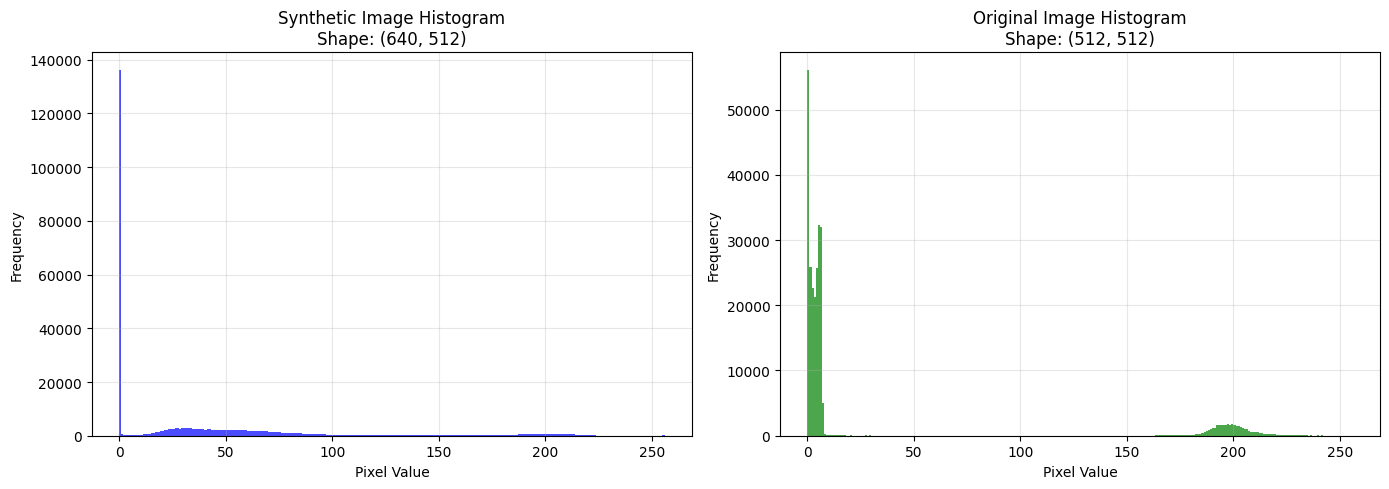

In [6]:
# Load one sample from each for histogram comparison
syn_img = cv2.imread(synthetic_files[0], cv2.IMREAD_GRAYSCALE)
orig_img = cv2.imread(original_files[0], cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Synthetic histogram
axes[0].hist(syn_img.flatten(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axes[0].set_title(f'Synthetic Image Histogram\nShape: {syn_img.shape}')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Original histogram
axes[1].hist(orig_img.flatten(), bins=256, range=[0, 256], color='green', alpha=0.7)
axes[1].set_title(f'Original Image Histogram\nShape: {orig_img.shape}')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 4: Side-by-Side Visual Comparison (10 Random Pairs)


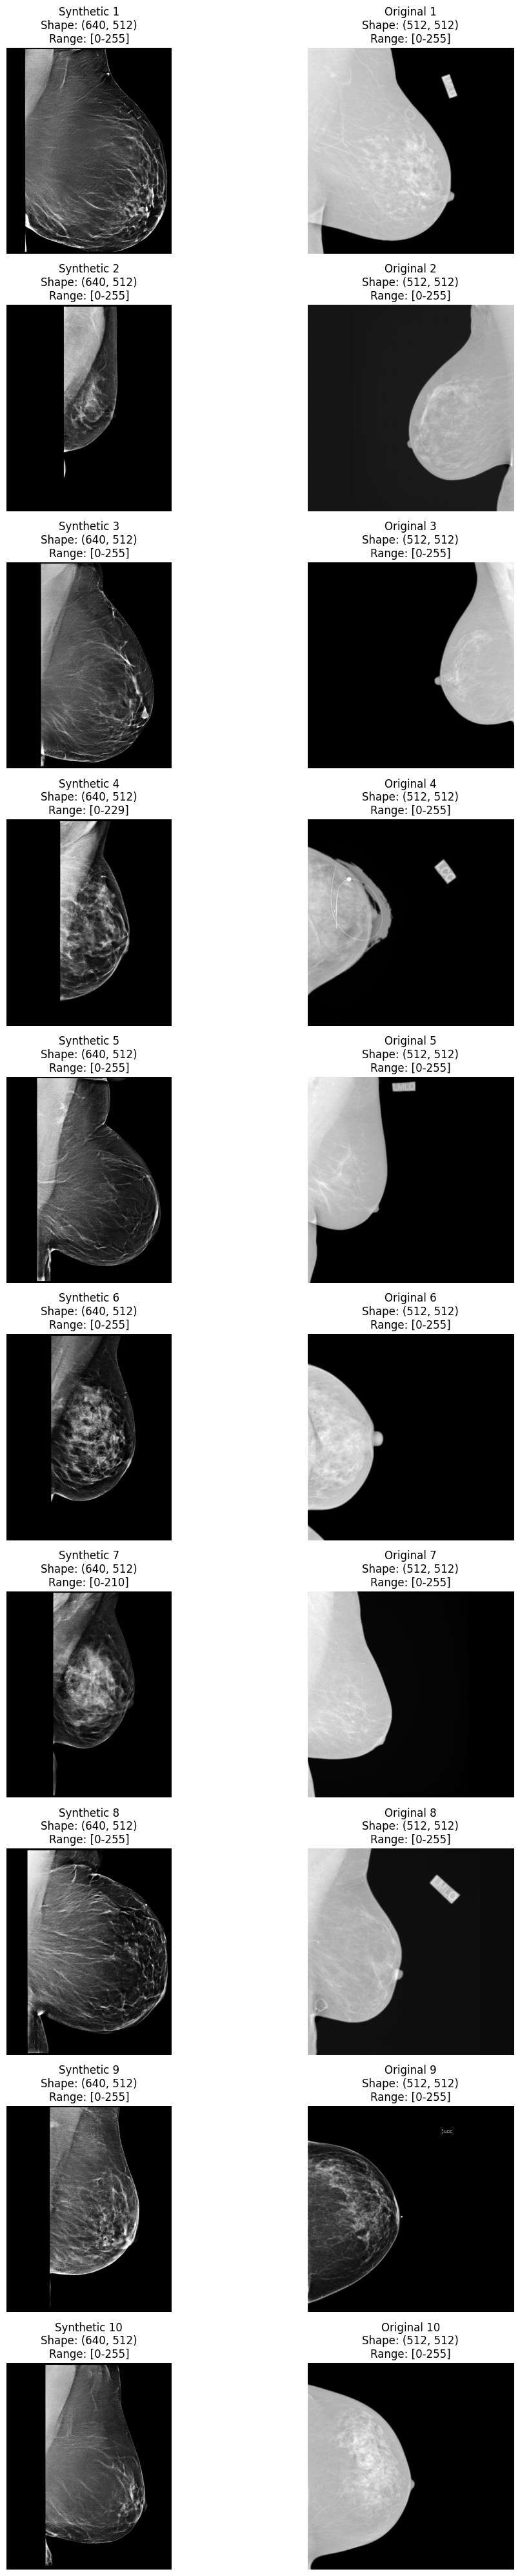


VISUAL COMPARISON COMPLETE
Check the images above to see dimension and appearance differences.


In [7]:
# Select 10 random images from each dataset for comparison
num_comparisons = 10
syn_compare = random.sample(synthetic_files, num_comparisons)
orig_compare = random.sample(original_files, num_comparisons)

fig, axes = plt.subplots(num_comparisons, 2, figsize=(12, 4*num_comparisons))

for i in range(num_comparisons):
    # Load images
    syn_img = cv2.imread(syn_compare[i], cv2.IMREAD_GRAYSCALE)
    orig_img = cv2.imread(orig_compare[i], cv2.IMREAD_GRAYSCALE)
    
    # Synthetic image
    axes[i, 0].imshow(syn_img, cmap='gray')
    axes[i, 0].set_title(f'Synthetic {i+1}\nShape: {syn_img.shape}\nRange: [{syn_img.min()}-{syn_img.max()}]')
    axes[i, 0].axis('off')
    
    # Original image
    axes[i, 1].imshow(orig_img, cmap='gray')
    axes[i, 1].set_title(f'Original {i+1}\nShape: {orig_img.shape}\nRange: [{orig_img.min()}-{orig_img.max()}]')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUAL COMPARISON COMPLETE")
print("="*70)
print("Check the images above to see dimension and appearance differences.")


## Step 5: Check for Text Annotations


In [8]:
# Check if images have text annotations by looking at edge regions
def has_text_annotation(img, threshold=0.1):
    """
    Simple heuristic: check if edges have unusually high pixel values
    (text annotations are often bright white on dark background)
    """
    h, w = img.shape
    edge_width = 50
    
    # Check all four edges
    top_edge = img[:edge_width, :]
    bottom_edge = img[-edge_width:, :]
    left_edge = img[:, :edge_width]
    right_edge = img[:, -edge_width:]
    
    # If edge mean is significantly higher than image mean, might have text
    img_mean = img.mean()
    edge_mean = np.mean([top_edge.mean(), bottom_edge.mean(), 
                         left_edge.mean(), right_edge.mean()])
    
    return edge_mean > img_mean * 1.5

# Check samples
syn_with_text = 0
orig_with_text = 0

check_sample_size = min(50, len(synthetic_files))

for f in tqdm(random.sample(synthetic_files, check_sample_size), desc="Checking synthetic for text"):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is not None and has_text_annotation(img):
        syn_with_text += 1

for f in tqdm(random.sample(original_files, check_sample_size), desc="Checking original for text"):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    if img is not None and has_text_annotation(img):
        orig_with_text += 1

print("\n" + "="*70)
print("TEXT ANNOTATION ANALYSIS")
print("="*70)
print(f"\nSynthetic images with possible text: {syn_with_text}/{check_sample_size}")
print(f"Original images with possible text: {orig_with_text}/{check_sample_size}")


Checking original for text: 100%|████████████████████████████████████████████████████| 50/50 [00:00<00:00, 288.21it/s]


TEXT ANNOTATION ANALYSIS

Synthetic images with possible text: 0/50
Original images with possible text: 2/50


## Final Summary: All Identified Differences


In [9]:
print("="*70)
print("FINAL SUMMARY: IDENTIFIED DIFFERENCES")
print("="*70)

print("\n1. DIMENSIONS:")
print(f"   Synthetic: {max(set(synthetic_dims), key=synthetic_dims.count)}")
print(f"   Original: {max(set(original_dims), key=original_dims.count)}")
if synthetic_dims != original_dims:
    print("   MISMATCH DETECTED")
else:
    print("   MATCH")

print("\n2. PIXEL VALUE RANGES:")
print(f"   Synthetic mean: {np.mean(synthetic_stats['mean']):.1f}")
print(f"   Original mean: {np.mean(original_stats['mean']):.1f}")
if abs(np.mean(synthetic_stats['mean']) - np.mean(original_stats['mean'])) > 10:
    print("   SIGNIFICANT DIFFERENCE")
else:
    print("   SIMILAR")

print("\n3. TEXT ANNOTATIONS:")
print(f"   Synthetic: {syn_with_text}/{check_sample_size} images")
print(f"   Original: {orig_with_text}/{check_sample_size} images")
if syn_with_text != orig_with_text:
    print("   DIFFERENCE DETECTED")
else:
    print("   SIMILAR")

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Resize synthetic images to match original dimensions")
print("2. Normalize pixel ranges to be uniform [0, 255]")
print("3. Remove text annotations if present")
print("4. Apply window/level normalization using metadata")
print("5. Create final identical datasets for fair comparison")
print("\nProceed to Notebook 10 to implement these fixes.")


FINAL SUMMARY: IDENTIFIED DIFFERENCES

1. DIMENSIONS:
   Synthetic: (640, 512)
   Original: (512, 512)
   MISMATCH DETECTED

2. PIXEL VALUE RANGES:
   Synthetic mean: 27.7
   Original mean: 54.5
   SIGNIFICANT DIFFERENCE

3. TEXT ANNOTATIONS:
   Synthetic: 0/50 images
   Original: 2/50 images
   DIFFERENCE DETECTED

NEXT STEPS:
1. Resize synthetic images to match original dimensions
2. Normalize pixel ranges to be uniform [0, 255]
3. Remove text annotations if present
4. Apply window/level normalization using metadata
5. Create final identical datasets for fair comparison

Proceed to Notebook 10 to implement these fixes.
